# Clustering & PCA Assignment 

##### HELP international is an international humanitarian NGO organization with the objective is to fight against  the poverty and provide a support to the backward countries during natural calamities and disasters. The provided data set contain the socio-economic and health factors represent the countries development position. 


- ### Business Objective 

    - identify  countries with similar socio-economic and health factors and group them as a different clusters.

- ### Approaches
    - Perform Exploratory data analysis (Data cleaning, univerent analysis,  Univerient and Bivariate analysis to understand the data.
    - perform Outlier analysis 
    - Perform PCA for dimensionality reduction 
    - perform K-Means clustering & Hierarchical clustering 
    - Analyze  the cluster and identify the cluster which need dire need of aid by comparing gdpp, child_mort and income
    - visualize the cluster's
    - suggest final list of 5 countries that need direst need of aid


In [1]:
# Import required Libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

#libraries used for data sclaing and preprocessing 
from sklearn.preprocessing import StandardScaler 

#Libraries for PCA
from sklearn.decomposition import PCA
from sklearn.decomposition import IncrementalPCA

#clustering libaries
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

#Metrics and measures 
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)

from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))
    

    
    

#Data Path 

source_data_file = f"Data\\Country-data.csv"

In [2]:
# loading data 

ds_data =pd.read_csv(source_data_file)

printmd("### Countries Data Set")
print(ds_data.info())

printmd("### Sample Data")
ds_data.head()

### Countries Data Set

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
country       167 non-null object
child_mort    167 non-null float64
exports       167 non-null float64
health        167 non-null float64
imports       167 non-null float64
income        167 non-null int64
inflation     167 non-null float64
life_expec    167 non-null float64
total_fer     167 non-null float64
gdpp          167 non-null int64
dtypes: float64(7), int64(2), object(1)
memory usage: 13.1+ KB
None


### Sample Data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
# Verify if data contain any duplicate rows 

printmd(f"#### Data contain duplicates <font color ='green'>: { ds_data.country.duplicated().any() }  </font>")

ds_data.describe()

#### Data contain duplicates <font color ='green'>: False  </font>

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [4]:
#verify data contain any null values

ds_data.isnull().sum(axis =0)

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

### Review Remaks 

- Data set contain <b> 167 </b> observations with <b> 10 </b> columns
- Only country name is in text form remaining all columns are numerical out of which income and gdpp are in integer remaining are decimal
- <font color="green"> <b> No duplicates </b> </font> are found in the data set"
- imports and exports for some countries seems unreasonable, these both columns are capturing % to the GDP in this case maximum values indicating of  174% and 200% remated to the export and imports need to be reviewed 
- child mortality  rate is STD indicating higher spread of the data need to visualize for better understanding
- Minimum inflation indicating <font color="red"> <b> -4.2 (negative) </b> </font> need to review as per definition this could happen only when the supply of goods higher than demand of goods.


## Univarient analysis

### TOP & LOW Values in the data set provided

child_mort <b> High 5 </b>: ['Haiti', 'Sierra Leone', 'Chad', 'Central African Republic', 'Mali'] <b> Low 5 </b> ['Iceland', 'Luxembourg', 'Singapore', 'Finland', 'Sweden']

exports <b> High 5 </b>: ['Singapore', 'Luxembourg', 'Malta', 'Ireland', 'Seychelles'] <b> Low 5 </b> ['Myanmar', 'Timor-Leste', 'Eritrea', 'Burundi', 'Nepal']

health <b> High 5 </b>: ['United States', 'Micronesia, Fed. Sts.', 'Sierra Leone', 'Netherlands', 'France'] <b> Low 5 </b> ['Qatar', 'Myanmar', 'Pakistan', 'Congo, Rep.', 'Turkmenistan']

imports <b> High 5 </b>: ['Singapore', 'Malta', 'Luxembourg', 'Seychelles', 'Lesotho'] <b> Low 5 </b> ['Myanmar', 'Brazil', 'Japan', 'United States', 'Argentina']

income <b> High 5 </b>: ['Qatar', 'Luxembourg', 'Brunei', 'Kuwait', 'Singapore'] <b> Low 5 </b> ['Congo, Dem. Rep.', 'Liberia', 'Burundi', 'Niger', 'Central African Republic']

inflation <b> High 5 </b>: ['Nigeria', 'Venezuela', 'Mongolia', 'Timor-Leste', 'Equatorial Guinea'] <b> Low 5 </b> ['Seychelles', 'Ireland', 'Japan', 'Czech Republic', 'Slovenia']

life_expec <b> High 5 </b>: ['Japan', 'Singapore', 'Switzerland', 'Iceland', 'Australia'] <b> Low 5 </b> ['Haiti', 'Lesotho', 'Central African Republic', 'Zambia', 'Malawi']

total_fer <b> High 5 </b>: ['Niger', 'Chad', 'Mali', 'Congo, Dem. Rep.', 'Burundi'] <b> Low 5 </b> ['Singapore', 'South Korea', 'Hungary', 'Moldova', 'Bosnia and Herzegovina']

gdpp <b> High 5 </b>: ['Luxembourg', 'Norway', 'Switzerland', 'Qatar', 'Denmark'] <b> Low 5 </b> ['Burundi', 'Liberia', 'Congo, Dem. Rep.', 'Niger', 'Sierra Leone']

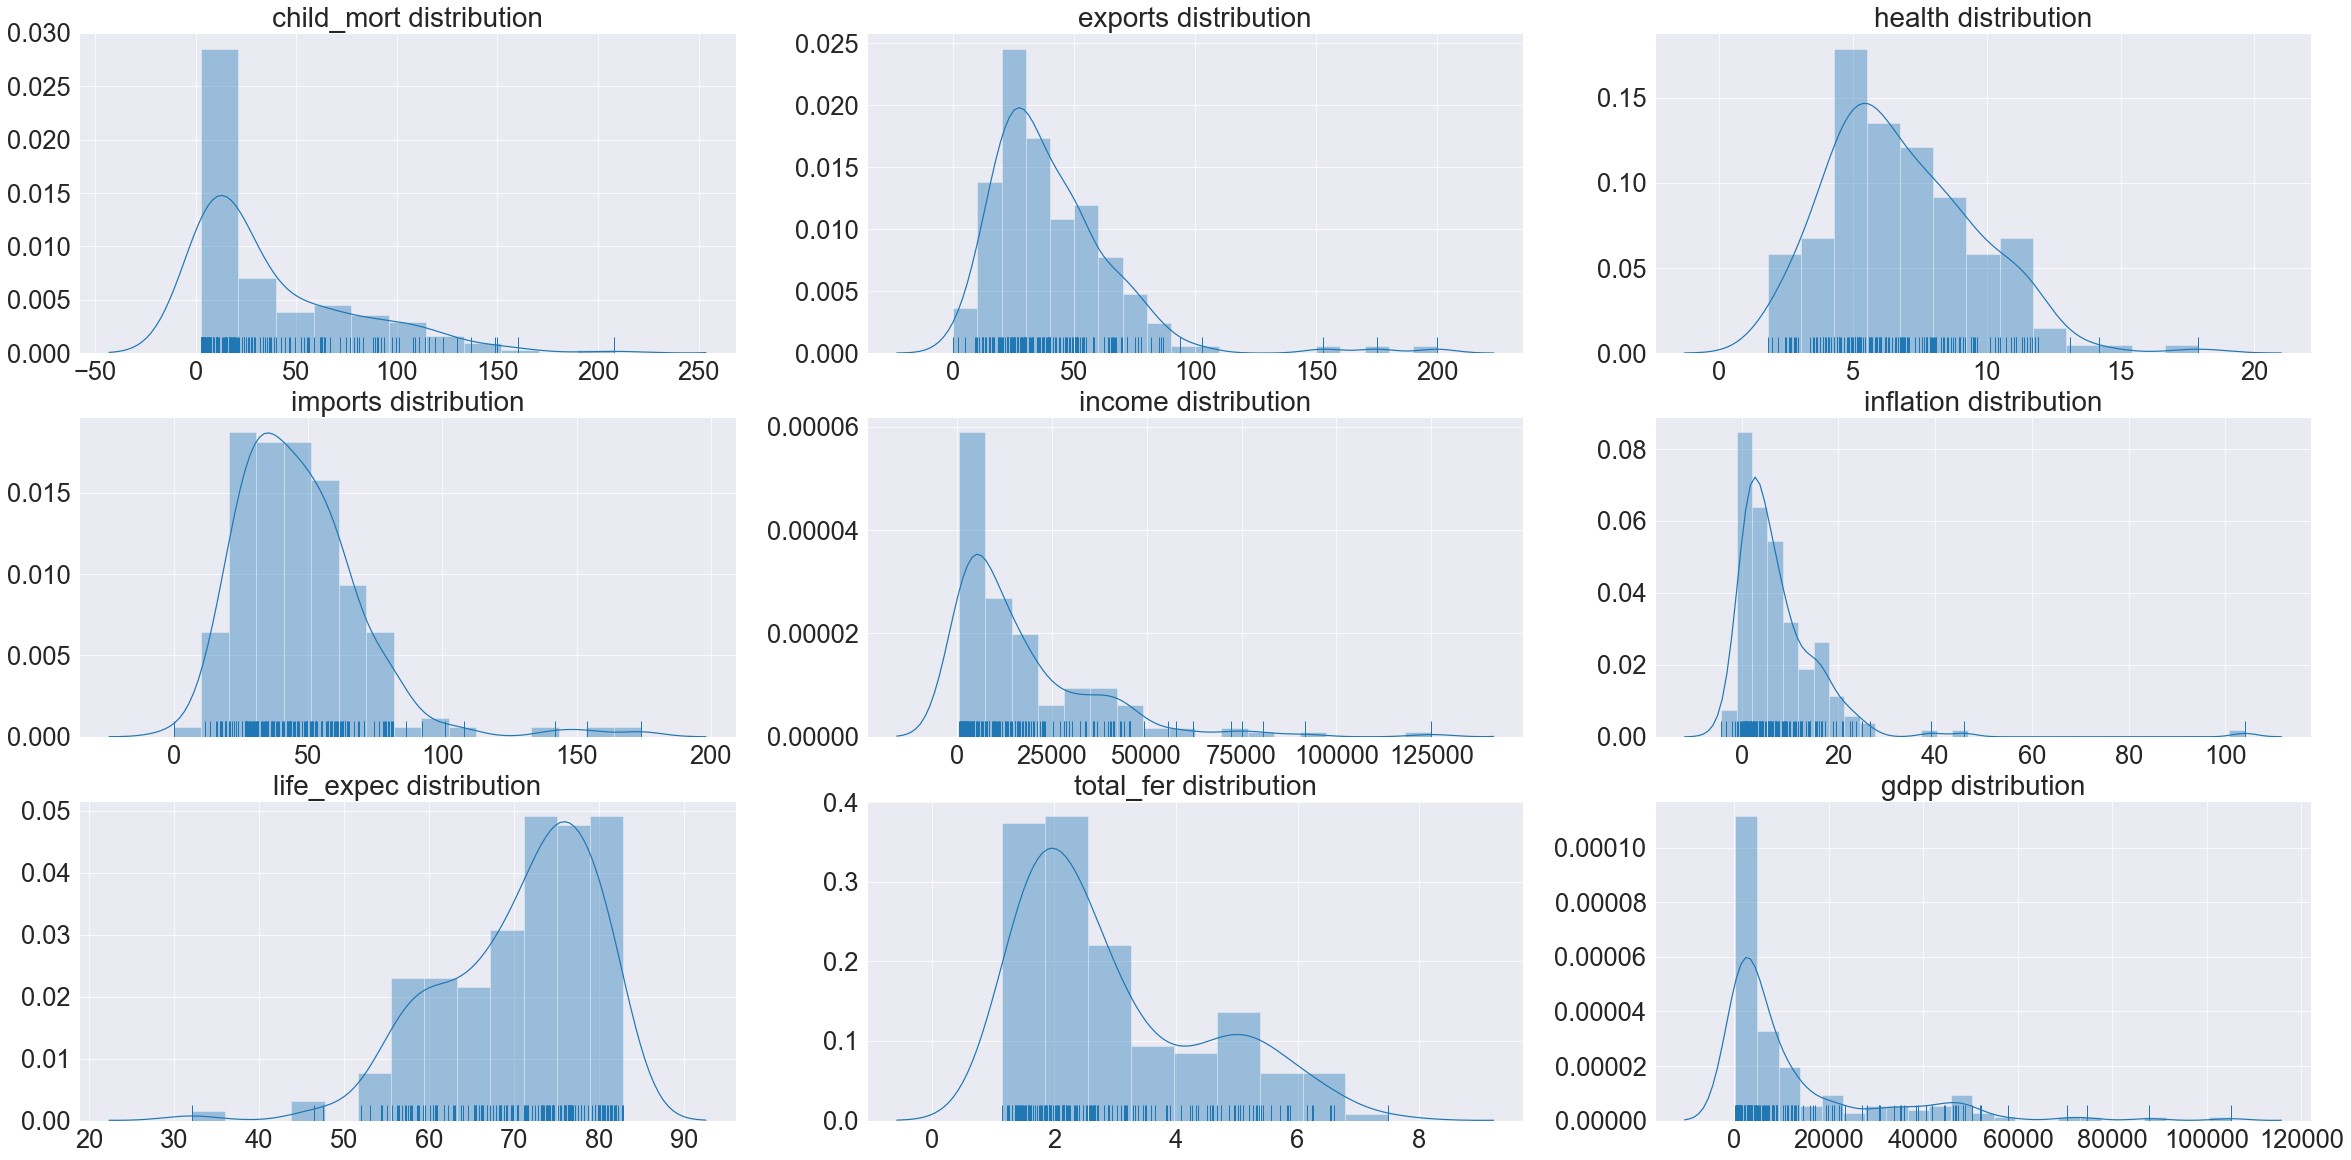

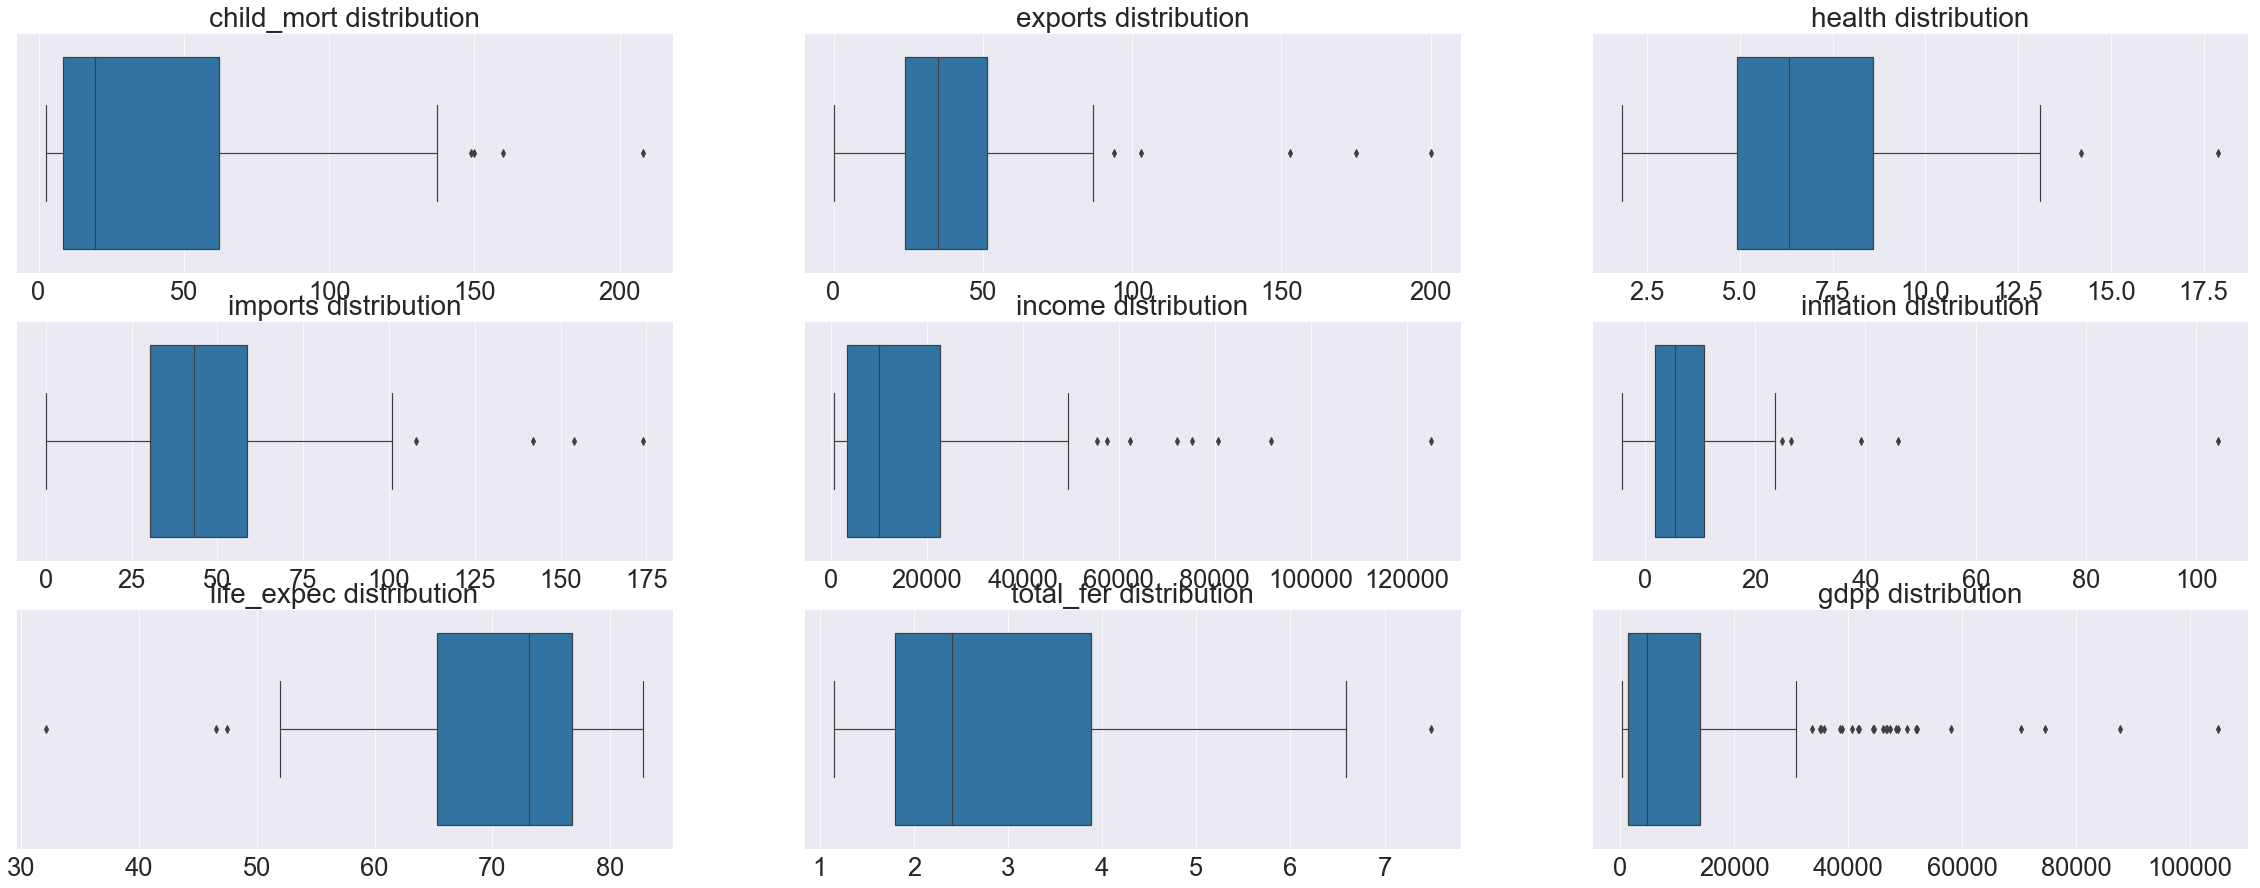

In [5]:
# performing univarient analysis

printmd("### TOP & LOW Values in the data set provided")
for i in range(1,ds_data.shape[1]):
    temp_high_5 =ds_data[["country",ds_data.columns[i]]].sort_values(by = ds_data.columns[i],ascending = False).country[:5].tolist()
    temp_low_5 =ds_data[["country",ds_data.columns[i]]].sort_values(by = ds_data.columns[i],ascending = True).country[:5].tolist()
    printmd(f"{ds_data.columns[i]} <b> High 5 </b>: {temp_high_5} <b> Low 5 </b> {temp_low_5}")   

#Prepare list of numarical columns list
numaric_columns = ds_data.columns.tolist()[1:]

plt.figure(figsize=(40,20))
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=2.9) 


#ploating distribution plots
for i in range(0,len(numaric_columns)):
    plt.subplot(3,3,i+1)
    plt.title(numaric_columns[i] + " distribution")
    sns.distplot(ds_data[[numaric_columns[i]]],rug=True)
    
plt.show()
plt.figure(figsize=(40,15))
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=2.9) 
plt.subplots_adjust( wspace=0.2, hspace=0.2)

# PLOTING BOXPLOTS FOR ALL NUMARIC COLUMNS 
for i in range(0,len(numaric_columns)):
    plt.subplot(3,3,i+1)
    
    plt.title(numaric_columns[i] + " distribution")
    sns.boxplot(ds_data[[numaric_columns[i]]])
    

### Review remaks 

- Few countries like Singapore, Malta, Seychelles indicating highr export and as well as higher import ratio to their GDP which indicates these countries should have limited sources however they also could be equipped with the specific high availability of specialized resources.
- Qatar indicating that income and GDPP both high but indicating low spending to the high which indiating that general health conditions and standards are very good.
- need to review bivariate analysis to understand correlations between key numerical variables.

- chaild_mortality distribution indicating that major number of countries having low mortality rate for 1000 live births however few countries are having very high as more than 150 ++ such as  Haiti', 'Sierra Leone', 'Chad', 'Central African Republic', 'Mali commonly these countries appeared to be mostly low income countries 

- export, imports and health distribution indicating semi normal distributions such as mean is nearly close to median expect few numbers far away fron center.

- life_expect distribution is also indicating near to normal distribution except few countries are indicating very low such as Haiti', 'Lesotho', 'Central African Republic', 'Zambia', 'Malawi'

- <b> Few columns such as chaild_mort / export /  health / import /  Inflation are appeared to be % but numbers are provided in the form of decimal's and also indicating few ouliers that is beyond 100% </b>

- GDPP also indicating some extreme values.


### Perform Pair plots to understand the relationships between numerical variables


<Figure size 1440x1440 with 0 Axes>

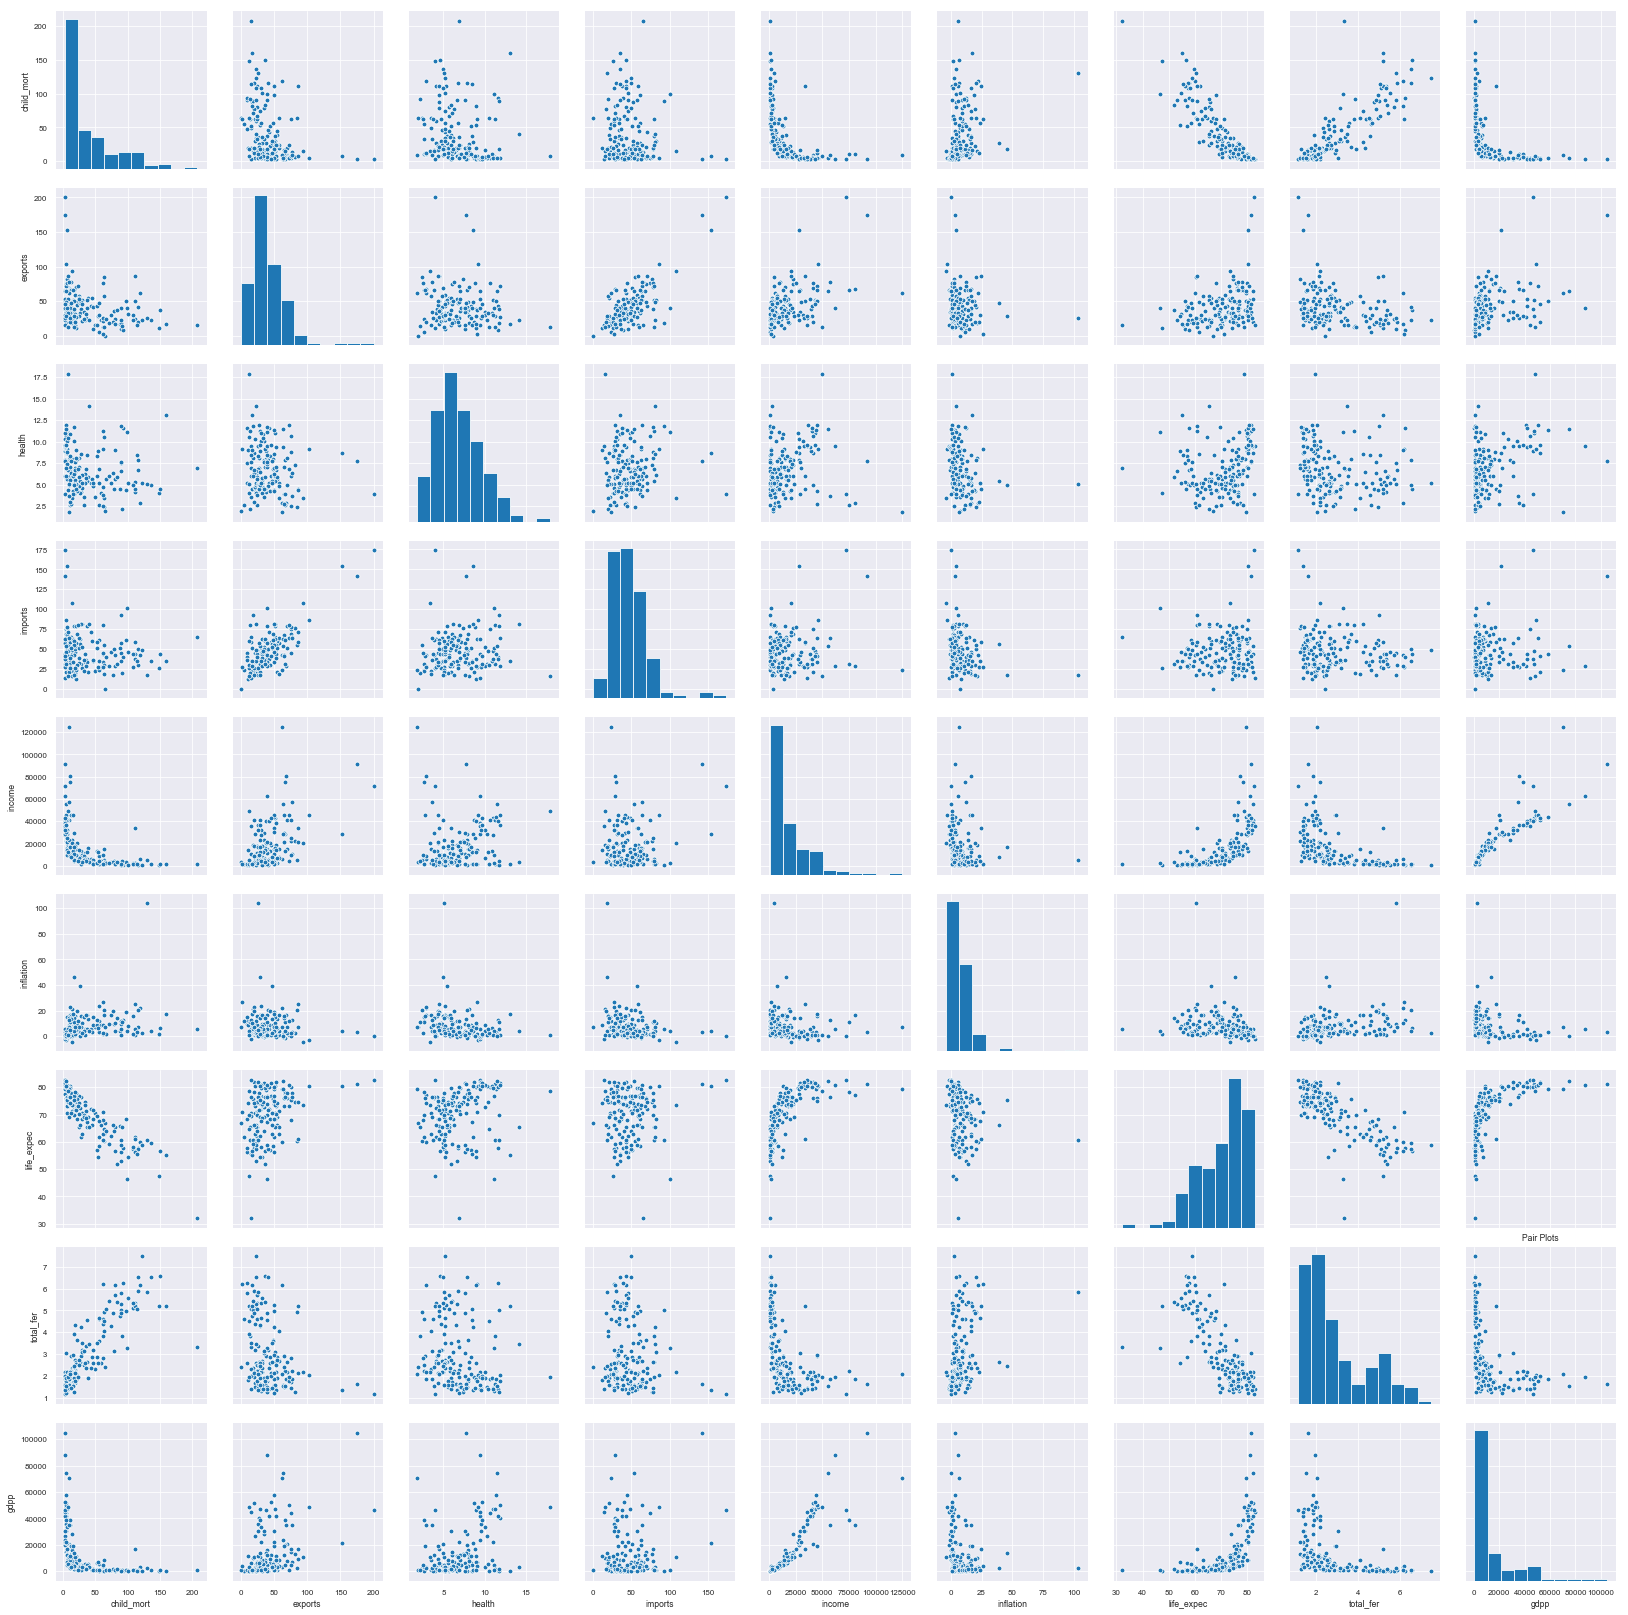

In [6]:
# pair plot
plt.figure(figsize=(20,20))
sns.set_context("paper", font_scale=0.9) 
sns.pairplot(ds_data)
plt.title("Pair Plots")
plt.show()

#### Review Remaks

- child_mort is indicating -ve relationship with gddp,life_exp,income at the same time indicating higher +ve correlation between fertility rates
- export indicating +ve correlation with the income
- health spending rate is not indicating any strong relationship with other numerical  variables 
- income indicating higher +ve correlation with income
- inflation is not indicating any strong correlation 
- life_expec indicating higher correlation with the GDPP and income. indicating -ve correlation with fertility rates and child mortality

## Data Cleaning 

>-  Covert export /  import / health/ Inflation into percentages and replace 
>-  Calculate export and import as absolute value over per person export and per person import (based on the value provided per person GDP)
>-  Child_mort is expressed as per 1000 to express values per 100% we will going to devide by 1000 
>-  Treat the remaining variables such as income / life_expec / total_fer and GDP by replaning any value beyond quantile of 0.05 or 0.95 to reset with these values respectively

In [7]:
ds_data_clean = ds_data.copy()
ds_data_clean=ds_data_clean.drop("country",axis=1)


# covert numarical numbers to %
ds_data_clean[["exports","health","imports","inflation"]] = ds_data_clean[["exports","health","imports","inflation"]]/100

# prepare absolute values for exports /  health and imports based on the GDP per captia derived fields indicates export and import per person GDP
ds_data_clean.exports = ds_data_clean.exports *ds_data_clean.gdpp 
ds_data_clean.imports = ds_data_clean.imports *ds_data_clean.gdpp 
ds_data_clean.health = ds_data_clean.health *ds_data_clean.gdpp 

#child mortality rate is provided per 1000 insted of that convert it to 100
ds_data_clean.child_mort = ds_data_clean.child_mort / 1000


#method for treating outliers. if any value beoynd 0.5 and 0.95 quantile ranges are considerer to be outliers and replace these elements
#with the bounderies

def reset_bounderies(column_name):
    _temp_percet = ds_data_clean[column_name].quantile([0.05,0.90]).values
    ds_data_clean[column_name]=ds_data_clean[column_name].apply(lambda x:  _temp_percet[0] if x < _temp_percet[0] else x )
    ds_data_clean[column_name]=ds_data_clean[column_name].apply(lambda x:  _temp_percet[1] if x > _temp_percet[1] else x )
    

# apply boundery treatment for each columns
for i in ds_data_clean.columns:
    reset_bounderies(i)


#Scaling the remaining fields 
_scaler = StandardScaler()

cols = ds_data_clean.columns
ds_data_clean[cols]=_scaler.fit_transform(ds_data_clean[cols])
#ds_data_clean=ds_data_clean.drop(["imports","exports","life_expec"],axis=1)
#ds_data_clean=ds_data_clean.drop("income",axis=1)

ds_data_clean.describe().round(3)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000,167.000,167.000,167.000,167.000,167.000,167.000,167.000,167.000
mean,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-0.960,-0.795,-0.690,-0.858,-1.026,-1.162,-1.892,-1.100,-0.794
25%,-0.816,-0.731,-0.647,-0.764,-0.869,-0.871,-0.689,-0.801,-0.731
50%,-0.485,-0.504,-0.446,-0.483,-0.386,-0.231,0.297,-0.348,-0.491
75%,0.798,0.433,0.095,0.652,0.554,0.727,0.764,0.736,0.188
max,1.940,2.219,2.447,2.114,1.902,1.780,1.219,1.798,2.196


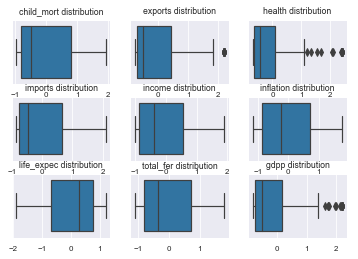

In [8]:
#Visualize the distributaion after scaling and data cleaning

for i in range(0,len(numaric_columns)):
    plt.subplot(3,3,i+1)
    
    plt.title(numaric_columns[i] + " distribution")
    sns.boxplot(ds_data_clean[[numaric_columns[i]]])

### Review Remaks

- after scaling is done and treat the ouliers summary statstics and dist5ributions looks reasonable

## PCA for dimensionality reduction
- Performing PCA on numarical fields
- Review PCA explaining 
- Analyse the PCA components 

In [9]:
#creating of PCA component
pca = PCA(svd_solver='randomized', random_state=42)


# executing PCA
pca.fit(ds_data_clean)

printmd(f"### PCA components are in the share of {pca.components_.shape}")
pca.components_

### PCA components are in the share of (9, 9)

array([[-3.19736513e-01,  3.56472200e-01,  3.49296609e-01,
         3.69936643e-01,  3.73484179e-01, -1.76493030e-01,
         3.38842557e-01, -3.00312132e-01,  3.69043378e-01],
       [ 4.83615819e-01,  3.06927657e-01,  2.59293155e-01,
         2.39130703e-01,  1.86093786e-01,  1.50027157e-01,
        -3.61318060e-01,  5.28901004e-01,  2.82964067e-01],
       [-1.47160095e-01,  9.01186552e-02, -1.24479008e-01,
        -3.29451203e-02,  1.72735327e-01,  9.47432418e-01,
         1.32415666e-01, -9.10148235e-02,  1.89431367e-02],
       [ 7.87569702e-03, -4.96814758e-01,  6.69056790e-01,
        -3.94281268e-01, -5.40234150e-02,  1.08905789e-01,
         2.24185272e-01,  1.34176839e-01,  2.58798963e-01],
       [ 1.25488998e-01, -8.87955081e-02,  2.18881306e-01,
        -5.68518639e-02,  4.92356382e-02,  7.15669726e-02,
        -6.66348998e-01, -6.82992708e-01,  8.47390273e-02],
       [-7.87642798e-01, -5.19514786e-02,  7.66061064e-02,
         3.01233012e-02, -1.88770352e-03, -3.017681

#### Since we are having 9 numarical variables. PCA components are produced with the range of 9 X 9 Matrix

### Explained Varience by the Principal components

PCA Varience : [71.  13.2  9.5  2.7  1.6  0.8  0.7  0.2  0.1]
PCA Cumulative Varience : [ 71.  84.  94.  96.  98.  99. 100. 100. 100.]


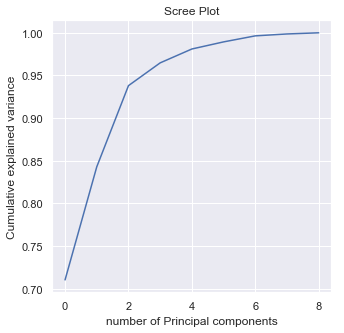

In [10]:
#explained Varience by PC's 
printmd("### Explained Varience by the Principal components")
print("PCA Varience :" , pca.explained_variance_ratio_.round(3) *100)
print("PCA Cumulative Varience :" , ( np.cumsum(pca.explained_variance_ratio_) *100).round())

sns.set()


plt.figure(figsize = (5,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of Principal components')
plt.ylabel('Cumulative explained variance')
plt.savefig('pca_no')
plt.title("Scree Plot")
plt.show()


### Review Remarks 

- 96% of varience explained by the first 4 PC's hence we will go with the 4 PC's which will compress the 9 numarical columns to the 4 
- first PC itself explaining 71% of varience
- Scree plot explaining how the varience explained over the each variables


#### Understand the components explaining high varience of PC1 and PC2 which together explaining 84% of varience

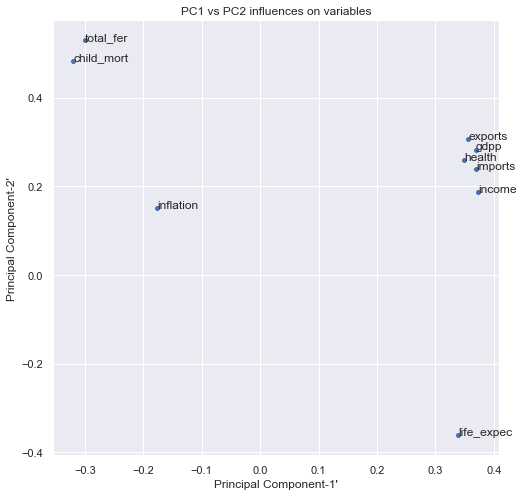

In [11]:
# Understand the components explaining high varience

import random

pc_analysis = pd.DataFrame()
pc_analysis["Variable"] = ds_data_clean.columns
pc_analysis["PC1"] = pca.components_[0]
pc_analysis["PC2"] = pca.components_[1]
pc_analysis["PC3"] = pca.components_[2]
pc_analysis["PC4"] = pca.components_[4]

plt.figure(figsize=(8,8))
plt.title("PC1 vs PC2 influences on variables")
sns.scatterplot(pc_analysis.PC1, pc_analysis.PC2)
plt.xlabel("Principal Component-1'")
plt.ylabel("Principal Component-2'")

for i, varname in enumerate(pc_analysis.Variable):
        plt.annotate(varname, (pc_analysis.PC1[i],pc_analysis.PC2[i] ))
plt.show()

### Review Remaks 

- exports,gdpp,health,imports and income are having higher coefficients in both Principal Component
- Total_fer and child_mort are having higher coefficients in  PC-2 and lower value on PC-1 
- life expectation is having high coefficients in PC-1 and lower value in PC-2

<b><font color="green"> Since Scree Plot indicating cumulative variance of all numaric fields explained by the by 4 components of 96% we will redevelop PCA to include only 4 components </font></b>


shape of matrix:  (167, 4)


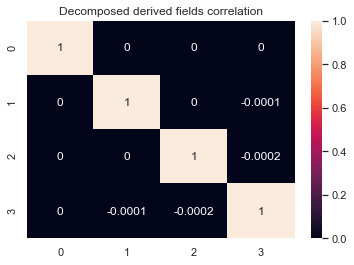

hopkins statistic on scaled data set after cleaning <b> 0.85 </b>

hopkins statistic on PCA Data set after cleaning <b> 0.802 </b>

In [12]:
#final PCA with 4 components data set
pca_final = IncrementalPCA(n_components=4)
df_pca = pca_final.fit_transform(ds_data_clean)
print("shape of matrix: " , df_pca.shape)

_corr = np.corrcoef(df_pca.transpose()).round(4)
sns.heatmap(_corr,annot = True)
plt.title("Decomposed derived fields correlation")
plt.show()


#perform hopkins statistic prove derived PCA featues and scaled features having clustering tendency or not 


#alogorithem
from random import sample
from numpy.random import uniform
from sklearn.neighbors import NearestNeighbors
import numpy as np
from math import isnan
 
def hopkins(X):
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n) 
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

printmd(f"hopkins statistic on scaled data set after cleaning <b> { hopkins(ds_data_clean).round(3) } </b>")
printmd(f"hopkins statistic on PCA Data set after cleaning <b> { hopkins(pd.DataFrame(df_pca)).round(3) } </b>")

### Review Remaks 

- Final Data Set for modeling is prepared with 4 components data set name pca_final
- above correlation heat map indicating that fields decomposed by PCA does't have any coorelation 
- <b> Both hopkins statistic for PCA features and cleaned scaled data indicating that data is having cluster tendency </b>

### Outlier analysis on PCA

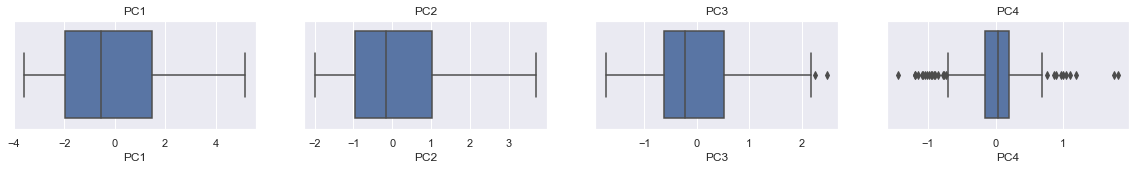

In [44]:
#performing outrlier analysis after PCA done for all PC's

_pca_outliers_ana=pd.DataFrame(df_pca.round(4))
_pca_outliers_ana.columns =["PC1","PC2","PC3","PC4"]

j =0
plt.figure(figsize=(20,2))
for i in _pca_outliers_ana.columns:
    j=j+1
    plt.subplot(1,4,j)
    sns.boxplot(_pca_outliers_ana[i])
    plt.title(i)
    
plt.show()

## Review Remaks 

- PC4 indicating high number of outliers we need to understand what are the factors influenceing PC4 for each coefients

In [54]:
pc_analysis.round(3)

,Variable,PC1,PC2,PC3,PC4
0,child_mort,-0.320,0.484,-0.147,0.125
1,exports,0.356,0.307,0.090,-0.089
2,health,0.349,0.259,-0.124,0.219
3,imports,0.370,0.239,-0.033,-0.057
4,income,0.373,0.186,0.173,0.049
5,inflation,-0.176,0.150,0.947,0.072
6,life_expec,0.339,-0.361,0.132,-0.666
7,total_fer,-0.300,0.529,-0.091,-0.683
8,gdpp,0.369,0.283,0.019,0.085


### Review Remaks

-- PC4  seems mainly explaining varience of Total_fer and distribution of total_fer is also indicating some skewness outliers came through PC4 can be ignored

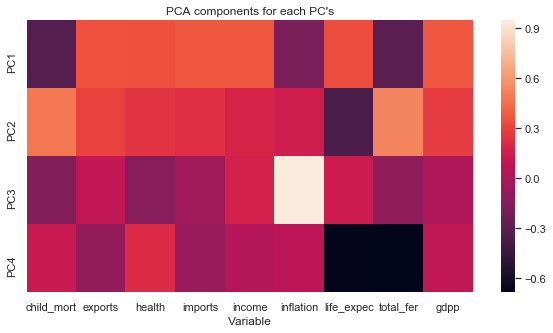

Variable,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,explained_varience
PC1,-0.320,0.356,0.349,0.370,0.373,-0.176,0.339,-0.300,0.369,0.710
PC2,0.484,0.307,0.259,0.239,0.186,0.150,-0.361,0.529,0.283,0.132
PC3,-0.147,0.090,-0.124,-0.033,0.173,0.947,0.132,-0.091,0.019,0.095
PC4,0.125,-0.089,0.219,-0.057,0.049,0.072,-0.666,-0.683,0.085,0.027


In [80]:
_te_PCA =pc_analysis.T.copy()
_te_PCA.columns =_te_PCA.loc["Variable"]
_te_PCA=_te_PCA.drop("Variable")

_te_PCA= _te_PCA.astype(float)
plt.figure(figsize=(10,5))
sns.heatmap(_te_PCA)
plt.title("PCA components for each PC's")
plt.show()
_te_PCA["explained_varience"] = pca_final.explained_variance_ratio_



_te_PCA.astype(float).round(3)

# Review Remaks:

- PC1 seems Majorly explaining of 71% of vareince entrire data set. and also it explains -ve corelation with the child mortality and infralation rate and total total_fer. and remaining all variables it has a +ve cofeicents which indicates it has +ve relationship with the dependent variables.
- PC2 seems explaining majorly on life expectation and income varience comparing with the PC-1
- PC3 Seems majorly explaining -ve correlation between exports,health and imports
- PC4 seems majorly explain the correlation between life excttation and total fer since weights of coefients are high comparing with the any other PC's and cofeients are -Ve.

### KMeans Clustering

- Perform  K Means clustering  with the initlization of K-Means++ approch 
- Identify the best k clusters by calculating Sum of squared distances of samples to their closest cluster center. 
- visualize the elbow line plot to derive number of clusters
- Evaluate intera and inter cluster variations through silhouette  score and hopkins statstics

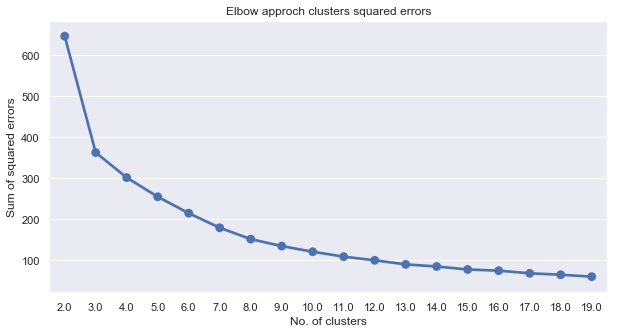

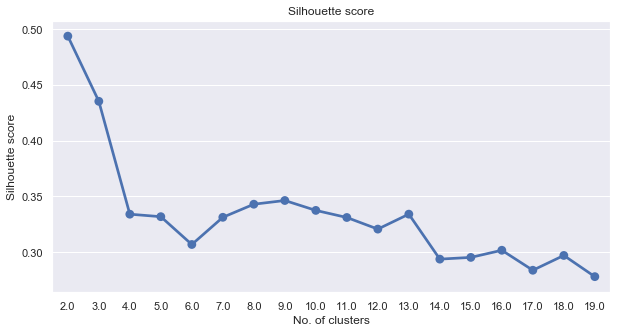

In [13]:
# choose optmial k value for clustering by iterative approch

_eval = pd.DataFrame()

for num_clusters in range(2,20):
    _kmeans = KMeans(n_clusters=num_clusters,init='k-means++', max_iter=100,random_state=42)
    _kmeans.fit(df_pca)    
    cluster_labels = _kmeans.labels_     
    silhouette_avg = silhouette_score(ds_data_clean, cluster_labels)
    _dic= {"num_clusters":num_clusters,"SSD":_kmeans.inertia_,"silhouette_Avg":silhouette_avg}
    _eval = _eval.append(_dic,ignore_index=True)
    

plt.figure(figsize=(10,5))
sns.pointplot(x="num_clusters", y="SSD", data=_eval)
plt.xlabel('No. of clusters')
plt.ylabel('Sum of squared errors')
plt.title("Elbow approch clusters squared errors")
plt.show()

plt.figure(figsize=(10,5))
sns.pointplot(x="num_clusters", y="silhouette_Avg", data=_eval)
plt.xlabel('No. of clusters')
plt.ylabel('Silhouette score')
plt.title("Silhouette score")
plt.show()


### Review Remaks 

- based on the above two parameters desided to go with the 5 cluster approch through K Means clustering algorithem
- clearn elbow is not shown after 3 k's clusters. inter cluster sum of squere constently reducing however silhouette score indicating that clusters with 4 and 5 indicating same perforformence hence it is desided to go with the <b> 5 cluster's </b>approch

In [14]:
#prepare final cluster with 5 clusters on PCA features and add it to the original data set

_kmeans = KMeans(n_clusters=5,init='k-means++', max_iter=100,random_state=42)
_kmeans.fit(df_pca)    
ds_data["KMeans_cls"]= _kmeans.labels_   

In [15]:
ds_data["KMeans_cls"].value_counts()

2    51
0    47
3    27
4    21
1    21
Name: KMeans_cls, dtype: int64

### Create Hierarchical Clustering

- create cluster through Hierarchical clustering 
- understand the difference between complete and single linkage
- visualize dedrogram 

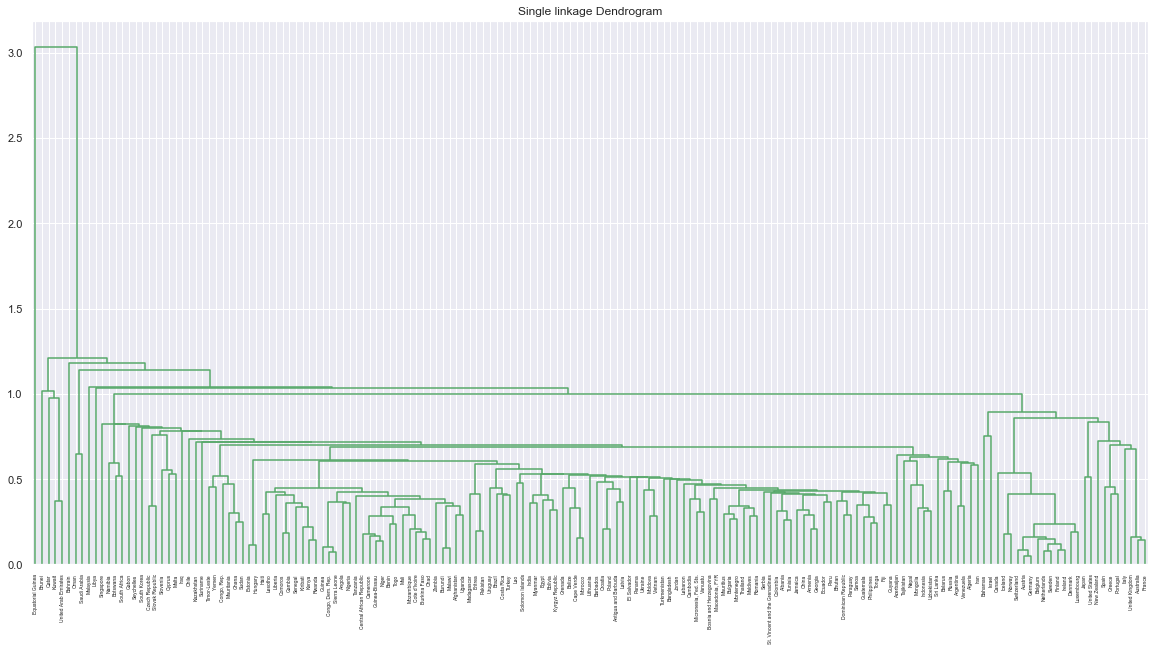

In [16]:
#Perform Single linkage Hierarchical Clustering

df_high = pd.DataFrame(df_pca).copy()
df_high["country"] = ds_data.country
df_high.set_index("country",inplace=True)

hc_cluster = linkage(df_high, metric='euclidean', method = "single")
plt.figure(figsize=(20,10))
dendrogram(hc_cluster,labels =df_high.index,color_threshold =5)
plt.title("Single linkage Dendrogram")
plt.show()

### Review Remaks 

- Single linkage is not clearly indicating any kind of clustering infact clusters formed is cluttering 

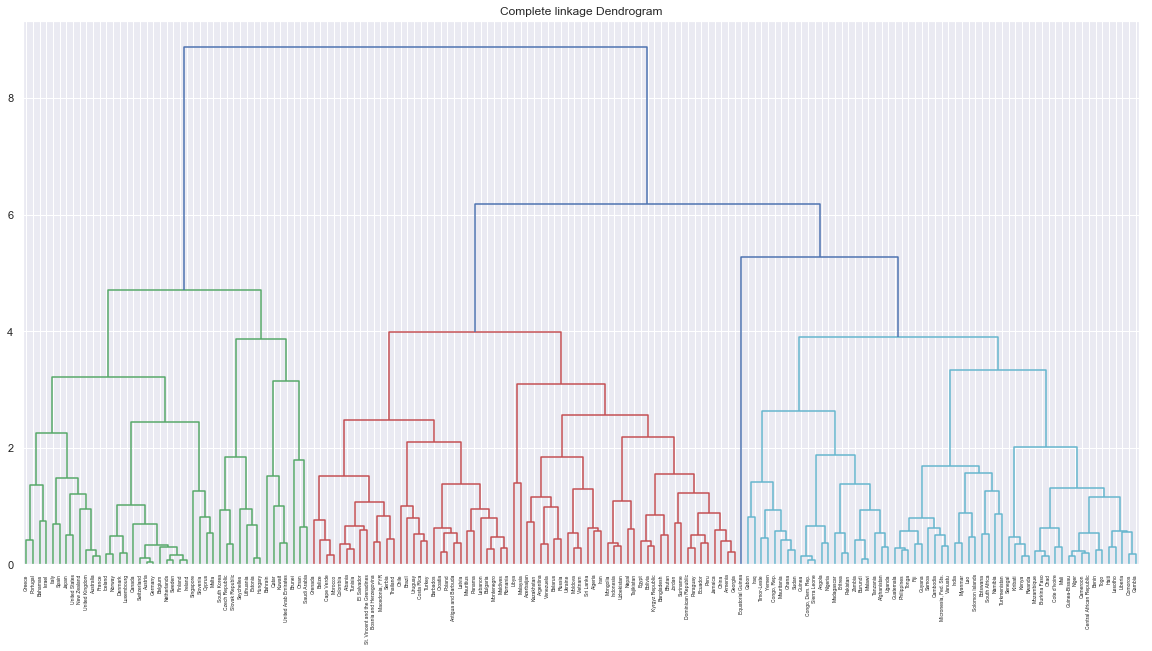

In [17]:
#performing complete linkage

hc_cluster = linkage(df_high, metric='euclidean', method = "complete")
plt.figure(figsize=(20,10))
dendrogram(hc_cluster,labels =df_high.index,color_threshold =5)
plt.title("Complete linkage Dendrogram")
plt.show()

#### Dendrogram analysis 
- observing dendrogram inidctain 3 optmial however to sych with approch what will cut the tree to generate 5 clusters. and comparing with the single linkage, complete linkage gives some kind of clean clustering

In [18]:
# Preparing 5 clusters with the Hierarchical Clustering using complete linkage method

ds_data["H_cls"] = cut_tree(hc_cluster, n_clusters=5).reshape(-1, )
ds_data.groupby("H_cls")["country"].count()

H_cls
0    59
1    64
2    29
3    14
4     1
Name: country, dtype: int64

In [19]:
#verifying why there is only one country in cluster number 5
ds_data[ds_data.H_cls ==4]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cls,H_cls
49,Equatorial Guinea,111.0,85.8,4.48,58.9,33700,24.9,60.9,5.21,17100,0,4


### Review Remaks 
- since we are having only one country forming part of cluster 5. we are going to create 6 clusters insted of 5 and replace this "Equatorial Guinea"
- with different cluster


In [20]:
# performing 6 clusters and reassigning Equatorial Guinea to 0 cluster 
_temp_h_CLS= cut_tree(hc_cluster, n_clusters=6).reshape(-1, )

_temp_h_CLS

#reseting cluster of country Equatorial Guinea
ds_data.loc[ds_data.country == 'Equatorial Guinea',["H_cls"]] =0 

ds_data.groupby("H_cls")["country"].count()

H_cls
0    60
1    64
2    29
3    14
Name: country, dtype: int64

### Remaks 

- compare the clusters created through K Means and hc_cluster
- Understand what are nature of these clusters 
- Understand the factors bringing these countries as group of clusters

In [21]:
#preparing final data set contain the original variables, Principal components  and clusters created

ds_final=ds_data.copy()
_temp=pd.DataFrame(df_pca)
_temp.columns=["PC1","PC2","PC3","PC4"]
ds_final=pd.concat([ds_final,_temp],axis=1)

ds_final.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_cls,H_cls,PC1,PC2,PC3,PC4
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0,0,-3.268808,1.453152,-0.327528,0.016973
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,1,-0.153253,-1.722256,-0.168230,0.043915
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,3,1,-0.829613,-0.750249,1.729912,0.356512
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0,0,-2.988598,1.916757,0.988560,0.068619
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,1,1.172464,-0.861738,-0.568681,-0.360816


In [22]:
# compare the clusters created through K Means and Hierarchical clustering
ds_final.groupby(["KMeans_cls","H_cls"])["country"].count().unstack().fillna(0)

H_cls,0,1,2,3
KMeans_cls,,,,
0,47.0,0.0,0.0,0.0
1,0.0,0.0,8.0,13.0
2,10.0,40.0,0.0,1.0
3,3.0,24.0,0.0,0.0
4,0.0,0.0,21.0,0.0


### Review Remaks 

- both methods choosen 47 countries in cluster 0. however there are around 13 countries are differently categorized by K Means clusters
- cluster 1 created by K means indicating mixed clusters of 3 and 4 formed by H Cluster
- cluster 2 in k means seems majorly matching with cluster 1 in H Cluster 
- cluster 3 in k means seems majorly matched with the cluster 2 created through H Cluster 

<b> Overall cluster dvinding clsuters by these two methods are relatively close each other <b>   


### Understand the Model clusters vs Principal components

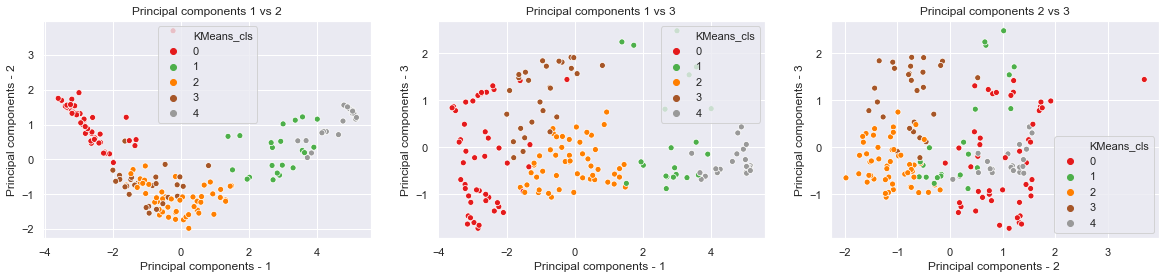

### Understand the mertis of Clusters Created by K Means Clusters

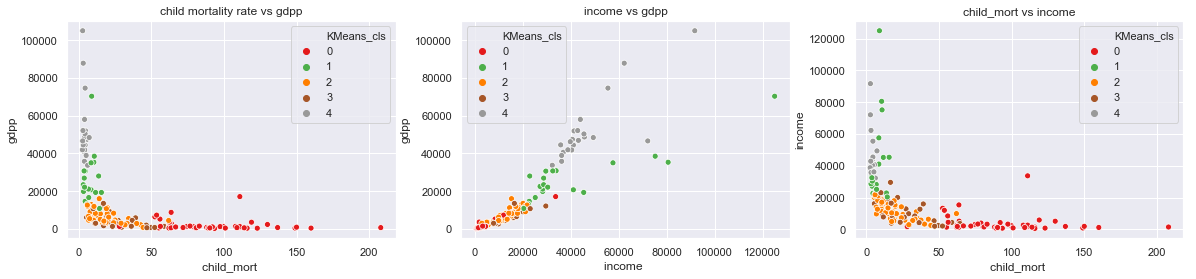

In [23]:
## Explore the K Means cluster indicates

printmd("### Understand the Model clusters vs Principal components")

plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
sns.scatterplot(data = ds_final,x="PC1",y="PC2",hue="KMeans_cls",palette="Set1",legend='full')
plt.xlabel("Principal components - 1 ")
plt.ylabel("Principal components - 2")
plt.title("Principal components 1 vs 2")


plt.subplot(1,3,2)
sns.scatterplot(data = ds_final,x="PC1",y="PC3",hue="KMeans_cls",palette="Set1",legend='full')
plt.xlabel("Principal components - 1 ")
plt.ylabel("Principal components - 3")
plt.title("Principal components 1 vs 3")

plt.subplot(1,3,3)
sns.scatterplot(data = ds_final,x="PC2",y="PC3",hue="KMeans_cls",palette="Set1",legend='full')
plt.xlabel("Principal components - 2 ")
plt.ylabel("Principal components - 3")
plt.title("Principal components 2 vs 3")
plt.show()





printmd("### Understand the mertis of Clusters Created by K Means Clusters")


plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
sns.scatterplot(data = ds_final,x="child_mort",y="gdpp",hue="KMeans_cls",palette="Set1",legend='full')
plt.xlabel("child_mort ")
plt.ylabel("gdpp")
plt.title("child mortality rate vs gdpp")

plt.subplot(1,3,2)
sns.scatterplot(data = ds_final,x="income",y="gdpp",hue="KMeans_cls",palette="Set1",legend='full')
plt.xlabel("income ")
plt.ylabel("gdpp")
plt.title("income vs gdpp")

plt.subplot(1,3,3)
sns.scatterplot(data = ds_final,x="child_mort",y="income",hue="KMeans_cls",palette="Set1",legend='full')
plt.xlabel("child_mort ")
plt.ylabel("income")
plt.title("child_mort vs income")
plt.show()

plt.show()

### Review Summary

- Based on the above it is clearly indicating that cluster =0 clutries (Red color) indicating backword countries interms of socio-economic factors.
- child mortality is very higth for those customers at the same time income (except one or two countries indicating income above 40k) is very low and gdpp is also very (Except one or two countries indicating GDPP of 40k)
- Principal components analysis indicates that how these countries are speratly divided and all the clusters forming mostly indicating clear seperation except few in comparsion with the PC-3


## cluster factor analysis

following activities need to be perform before concluding

- Understand the cluster center's such as median variation between clusters
- Name the clusters
- outlier analysis
- final recomendations

In [24]:
## Cluster centers (median's)
ds_final.groupby("KMeans_cls")[numaric_columns].median()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_cls,,,,,,,,,
0,90.2,23.8,5.66,42.7,1850,8.79,59.5,5.06,897
1,6.8,65.7,6.93,46.2,29600,2.01,77.5,1.72,22500
2,17.4,35.8,6.47,51.5,10500,3.80,74.1,2.14,5080
3,26.1,31.7,5.25,31.4,8430,14.20,70.4,2.41,2970
4,4.2,42.3,9.64,37.4,41400,1.05,81.0,1.87,46900


### Review Remaks 

- Based on median analysis it is clearly indicating that 
    - cluster - 0 indicating definitely backward  country all socio-economic indicator is poorly performing
    - cluster 2,3 are indicating devloping countries with countries median GDPP is far better than cluster zero  and child mortality rate at least two times lower than cluster-0
    -  cluster - 1,4 indicating developed countries all indicators are extreamly good

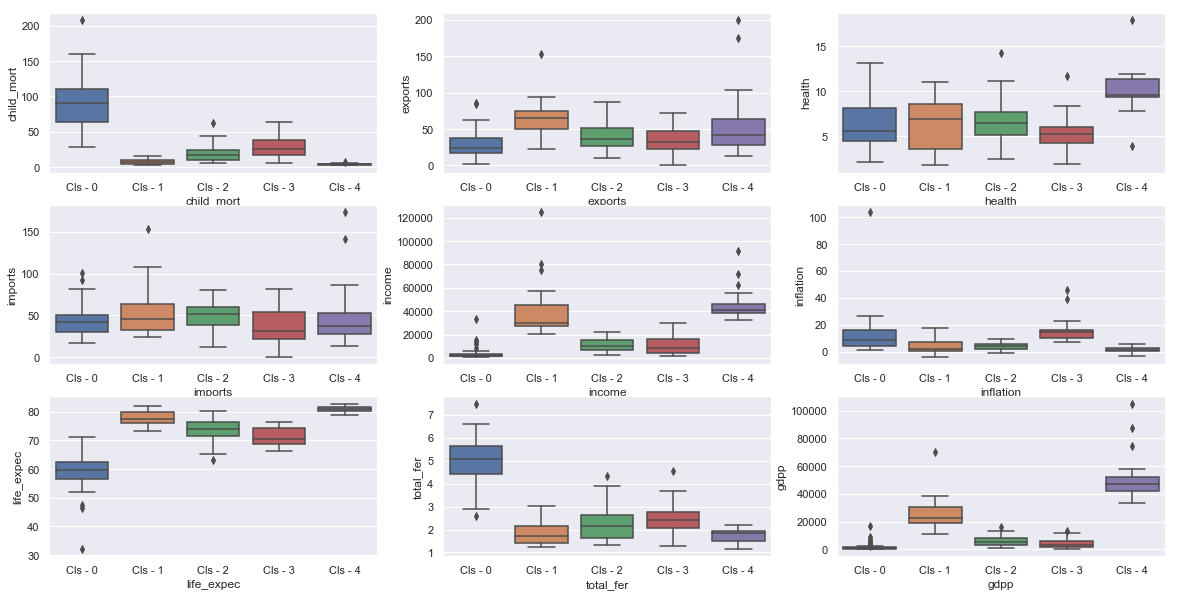

In [25]:
ds_final["class_label"] = "Cls - " + ds_final.KMeans_cls.astype(str)
plt.figure(figsize=(20,10))
for i in range(0,len(numaric_columns)):
    plt.subplot(3,3,i+1)
    sns.boxplot(data = ds_final.sort_values(by="class_label"),y=numaric_columns[i],x="class_label")
    plt.xlabel(numaric_columns[i])
    

### Review Remaks

- based on the cluster distrbution, Cluster 0 economically backward  countries clearly showing different for the following of GDPP /  Total_fer /  Life_expectation / income / child_mort variables from the other clusters
- however impots, Health and export indicates that clusters 0 has some similarities with the other clusters of 1,2,3 
- further bin the clusters in zero cluster to identify disprate need

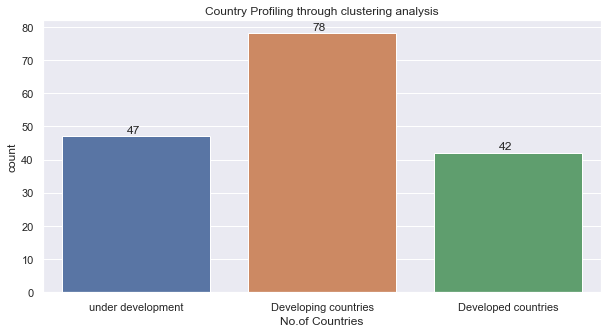

<b> Clsuter under development</b> ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']

<b> Clsuter Developing countries</b> ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Fiji', 'Georgia', 'Grenada', 'Guatemala', 'Guyana', 'India', 'Indonesia', 'Iran', 'Iraq', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Myanmar', 'Nepal', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Samoa', 'Serbia', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Suriname', 'Tajikistan', 'Thailand', 'Tonga', 'Tunisia', 'Turkey', 'Turkmenistan', 'Ukraine', 'Uruguay', 'Uzbekistan', 'Vanuatu', 'Venezuela', 'Vietnam']

<b> Clsuter Developed countries</b> ['Australia', 'Austria', 'Bahamas', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Portugal', 'Qatar', 'Saudi Arabia', 'Seychelles', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

In [26]:
_profiles={0: "under development",1: "Developed countries",2:"Developing countries",3:"Developing countries",4:"Developed countries"}
ds_final["Profile"] = ds_final.KMeans_cls.map(_profiles)

plt.figure(figsize=(10,5))
ax=sns.countplot(x="Profile", data=ds_final)
plt.title("Country Profiling through clustering analysis")
plt.xlabel("No.of Countries")
for p in ax.patches:
        ax.annotate('{:}'.format(p.get_height()), (p.get_x()+0.35, p.get_height()+1))
plt.show()



for i in ds_final['Profile'].unique():
    printmd(f"<b> Clsuter {i}</b> {list(ds_final[ds_final.Profile ==i].country)}")
    



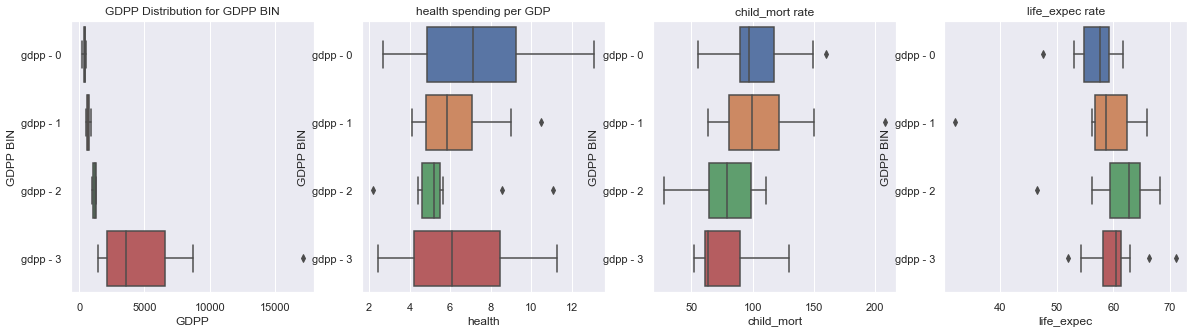

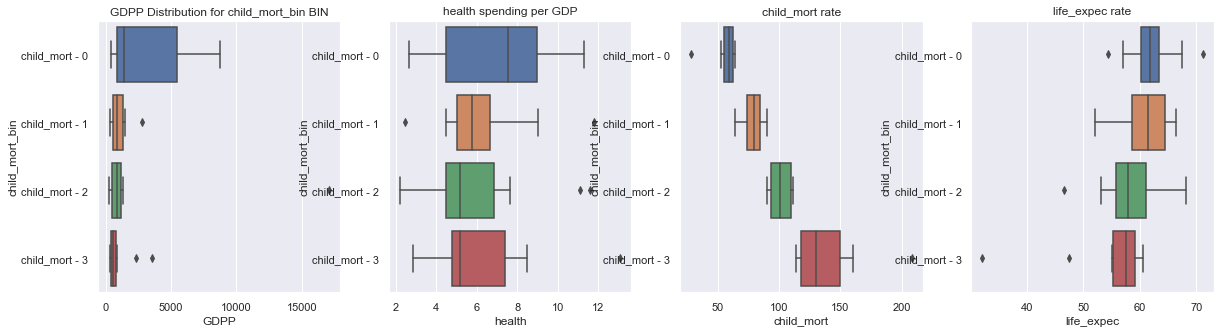

In [27]:
ds_focused=ds_final.loc[ds_final.KMeans_cls==0,numaric_columns + ["country"]]

ds_focused["gdpp_bin"]= pd.qcut(ds_focused['gdpp'], 4, labels=False)
ds_focused["child_mort_bin"]=pd.qcut(ds_focused['child_mort'], 4, labels=False)

ds_focused["gdpp_bin"] = "gdpp - " + ds_focused.gdpp_bin.astype(str)
ds_focused["child_mort_bin"] = "child_mort - " + ds_focused.child_mort_bin.astype(str)


# for the created BIN's through GDPP analyse the other variables
plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
sns.boxplot(data=ds_focused.sort_values(by="gdpp_bin"),x="gdpp",y="gdpp_bin")
plt.title("GDPP Distribution for GDPP BIN")
plt.xlabel("GDPP")
plt.ylabel("GDPP BIN")

plt.subplot(1,4,2)
sns.boxplot(data=ds_focused.sort_values(by="gdpp_bin"),x="health",y="gdpp_bin")
plt.title("health spending per GDP")
plt.xlabel("health")
plt.ylabel("GDPP BIN")

plt.subplot(1,4,3)
sns.boxplot(data=ds_focused.sort_values(by="gdpp_bin"),x="child_mort",y="gdpp_bin")
plt.title("child_mort rate")
plt.xlabel("child_mort")
plt.ylabel("GDPP BIN")


plt.subplot(1,4,4)
sns.boxplot(data=ds_focused.sort_values(by="gdpp_bin"),x="life_expec",y="gdpp_bin")
plt.title("life_expec rate")
plt.xlabel("life_expec")
plt.ylabel("GDPP BIN")
plt.show()


# for the created BIN through child_mortality rate per 1000 analyze the behiaour of other indicatros

plt.figure(figsize=(20,5))
plt.subplot(1,4,1)
sns.boxplot(data=ds_focused.sort_values(by="child_mort_bin"),x="gdpp",y="child_mort_bin")
plt.title("GDPP Distribution for child_mort_bin BIN")
plt.xlabel("GDPP")
plt.ylabel("child_mort_bin")

plt.subplot(1,4,2)
sns.boxplot(data=ds_focused.sort_values(by="child_mort_bin"),x="health",y="child_mort_bin")
plt.title("health spending per GDP")
plt.xlabel("health")
plt.ylabel("child_mort_bin")

plt.subplot(1,4,3)
sns.boxplot(data=ds_focused.sort_values(by="child_mort_bin"),x="child_mort",y="child_mort_bin")
plt.title("child_mort rate")
plt.xlabel("child_mort")
plt.ylabel("child_mort_bin")


plt.subplot(1,4,4)
sns.boxplot(data=ds_focused.sort_values(by="child_mort_bin"),x="life_expec",y="child_mort_bin")
plt.title("life_expec rate")
plt.xlabel("life_expec")
plt.ylabel("child_mort_bin")
plt.show()


#### Review Remaks 

- BIN's created through GDPP indicates BIN of Zero and one clearly indicating suffering with high child moratlity rate & low life expected rate and high spending for health
- BIN's created through child mortality rate clearly indicating that countries represent bin 3  is indicating suffering with low expected and low GDP

In [28]:
#list of counytries in  GDPP with 0 and 1 are 

lowest_GDPP= set(ds_focused[ds_focused.gdpp_bin=='gdpp - 0'].country)
low_gdpp= set(ds_focused[ds_focused.gdpp_bin=='gdpp - 1'].country)

highest_child_mort= set(ds_focused[ds_focused.child_mort_bin=='child_mort - 3'].country)
high_child_mort= set(ds_focused[ds_focused.child_mort_bin=='child_mort - 2'].country)


printmd(f"Countries with lowest GDPP are : <font color='red'>{lowest_GDPP}</font>")        
printmd(f"Countries with lowest GDPP are : <font color='red'>{low_gdpp}</font>")        
        
printmd(f"Countries with Highest child mortality rate are  : <font color='red'>{highest_child_mort}</font>")        
printmd(f"Countries with Highest child mortality rate are  : <font color='red'>{high_child_mort}</font>")  

countries_having_disperate_need = lowest_GDPP.intersection(highest_child_mort)
other_countries_need_priority_support = (lowest_GDPP | low_gdpp |highest_child_mort |high_child_mort).difference(countries_having_disperate_need)


printmd(f"<font color='red'>Common countries based on GDPP & child_mortality in very <b>  {sorted(countries_having_disperate_need)} </b></font>")

printmd(f"<font color='blue'>Countries need foucs on importent basis <b>  { sorted(other_countries_need_priority_support ) } </b></font>")

Countries with lowest GDPP are : <font color='red'>{'Guinea-Bissau', 'Eritrea', 'Mozambique', 'Niger', 'Madagascar', 'Sierra Leone', 'Togo', 'Central African Republic', 'Liberia', 'Burundi', 'Malawi', 'Congo, Dem. Rep.'}</font>

Countries with lowest GDPP are : <font color='red'>{'Tanzania', 'Chad', 'Gambia', 'Mali', 'Burkina Faso', 'Haiti', 'Rwanda', 'Afghanistan', 'Benin', 'Comoros', 'Guinea', 'Uganda'}</font>

Countries with Highest child mortality rate are  : <font color='red'>{'Guinea-Bissau', 'Angola', 'Chad', 'Niger', 'Mali', 'Burkina Faso', 'Central African Republic', 'Nigeria', 'Sierra Leone', 'Haiti', 'Congo, Dem. Rep.'}</font>

Countries with Highest child mortality rate are  : <font color='red'>{'Lesotho', 'Pakistan', 'Equatorial Guinea', 'Mozambique', 'Cameroon', 'Mauritania', "Cote d'Ivoire", 'Benin', 'Togo', 'Guinea', 'Burundi', 'Malawi'}</font>

<font color='red'>Common countries based on GDPP & child_mortality in very <b>  ['Central African Republic', 'Congo, Dem. Rep.', 'Guinea-Bissau', 'Niger', 'Sierra Leone'] </b></font>

<font color='blue'>Countries need foucs on importent basis <b>  ['Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Chad', 'Comoros', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gambia', 'Guinea', 'Haiti', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Nigeria', 'Pakistan', 'Rwanda', 'Tanzania', 'Togo', 'Uganda'] </b></font>

# Final Summary


Steps followed for performing analysis

- Review Source Data 
    - Observed  the data and verify if data elements having any notable missing values 
    - Observed  the data types
    - highlevel review the data distribution for each provided numeric  values
    - noticed countries with the high and low values for the each numeric  value 
    - notices countries forming in low GDPP and appeared to in low income as well as high child mortality
    - notices child mortality rate standard deviation is high 
    - noticed that some form of data is provided in the %
    - noticed trends between some important fields
    - noticed some values belong the quartiles ranges
    
    
    
- Data Cleaning 

    - Transform  all the percentage fields into the actual decimal points 
    - Transformed import, export and health to absolute values such as export per person and import per person and health spending per person instead  of leaving those values as percentage to GDP since we are having per person GDP 
    - Convert child mortality rate from 1000 instead of percentage to 100 
    - Teated ouliers by fixing boundaries for each fields if any boundaries below 0.05 or 0.95 quartiles ranges rearange these fields to boundaries to avid outliers influence
    - scale all the numerical variables
    
    
    
- PCA analysis 
    - Constructed PCA principal components
    - choosen 4 PC since 96% of variation been explained by these principal components 
    - Through hopkins statistics conformed that with using PC's we can go for clustering 
    - Validated PC's having any multicollinearity issue data inidcates all PC's indicated does't have any correlation
    

- Cluster creation

    - Performed K-Means clustering with the parameters of KMeans Plus Plus initialization 
    - Experimented with the different K’s between 2 and 20
    - Calculated both Sum of Square distances and Silhouette for each K’s 
    - Chosen k=5 based on these two measures 
    - Performed clustering through Hierarchical clustering with single linkage and noticed that most of data is grouped under the major one segment it reached to certain lowest levels. Visually not recognized any good clusters.
    - Remodeled based on complete clustering indicating data is grouped under the 3 segments. Since we have chosen K level 5 through K Means decided to cut the tree by separating 5 clusters. However noticed that one country alone forming one cluster. Hence again repertory the above step with the 6 clusters. After that re-categories Equatorial Guinea into lowest segment of 0 cluster.
    
    
- Cluster mertis and validations

    - Compare the clusters created between K Means and Hierarchical. Noticed that clusters are mostly similar each other except very few variations. 
    - Further studied reasons how and why these countries are common each other. Comparing the key indicators with child mortality rate , income , gdpp. Clearly clusters formed by K Means indicating higher similarities.
    - Validated Clusters by comparing relationship between principal components. And arrived a confidence that clusters created by K Means is nonrandom and having sufficient seminaries
    
- Understanding clusters 
    
    - Reviewed relationship between formed clusters with all the numeric fields. Noticed that cluster-0 [47 countries] indicating suffering countries 
    - Cluster -2[51 countries] & 3[27 countries] indicating developing countries all the median GDPP child mortality are  better than clusters-0
    - Cluster-1[21 countries] & Cluster-4[21 countries] clearly indicating developed countries
    



- Recommendations

    - Created binning based on the child mortality rate and GDPP.
    - Noticed that 0 bin, 1 bin created for the GDPP also indicating child mortality is high and income is low comparing with all other countries in this segment
    - Noticed that 2 and 3 bins created through child mortality also indicating low GDPP with low life expectation and health spending is also low comparing with the other countries in the same segment.
    - Prepared final countries listing low GDPP and high child mortalities <font color=red> <b> Central African Republic', 'Congo, Dem. Rep.', 'Guinea-Bissau', 'Niger', 'Sierra Leone' </b> </font> need disparate need for immediate support.
    - Also HELP need to focus other countries with the simlar problems <font color=red> <b> Afghanistan', 'Angola', 'Benin', 'Burkina Faso', 'Burundi', 'Cameroon', 'Chad', 'Comoros', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gambia', 'Guinea', 'Haiti', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Nigeria', 'Pakistan', 'Rwanda', 'Tanzania', 'Togo', 'Uganda'  </b> </font> indicating suffering with the low GDP and High child mortality rate.

    